# LoRA



3．LoRA（Low－Rank Adaptation）
原理
－假设 Transformer 中某些权重矩阵  $W \in \mathbb{R}^{d \times k}$  可以通过低秩分解适应新任务：

$$W^{\prime}=W+\Delta W, \quad \Delta W=A B, \quad A \in \mathbb{R}^{d \times r}, B \in \mathbb{R}^{r \times k}$$

-  $r \ll d, k \rightarrow $ 只训练  A, B  两个小矩阵
- 冻结原模型权重W，仅训练低秩矩阵
- 可在推理时合并权重，也可保持分离，实现多任务共享

In [1]:
from datasets import Dataset, load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorForSeq2Seq, TrainingArguments, Trainer

## 加载数据集/tokenizer 以及数据处理

In [2]:
data_path = "/root/autodl-tmp/dataset/alpaca-gpt4-data-zh/alpaca_gpt4_data_zh.json"
ds = load_dataset("json", data_files=data_path, split="train")

path = "model/Qwen3-0.6B"
tokenizer = AutoTokenizer.from_pretrained(path)
print("tokenizer.eos_token is: ", tokenizer.eos_token)

tokenizer.eos_token is:  <|im_end|>


In [3]:
def process_func(example):
    MAX_LENGTH = 256
    input_ids, attention_mask, labels = [], [], []

    instruction = tokenizer(
        "\n".join(["Human: " + example["instruction"], example["input"]]).strip() + "\n\nAssistant: "
    )

    response = tokenizer(example["output"] + tokenizer.eos_token)
    input_ids = instruction["input_ids"] + response["input_ids"]
    attention_mask = instruction["attention_mask"] + response["attention_mask"]
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"]

    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
        
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels
    }
tokenized_ds = ds.map(process_func, remove_columns=ds.column_names)
tokenized_ds, tokenizer.decode(tokenized_ds[1]["input_ids"])

(Dataset({
     features: ['input_ids', 'attention_mask', 'labels'],
     num_rows: 48818
 }),
 'Human: 三原色是什么？\n\nAssistant: 三原色通常指的是红色、绿色和蓝色（RGB）。它们是通过加色混合原理创建色彩的三种基础颜色。在以发光为基础的显示设备中（如电视、计算机显示器、智能手机和平板电脑显示屏）, 三原色可混合产生大量色彩。其中红色和绿色可以混合生成黄色，红色和蓝色可以混合生成品红色，蓝色和绿色可以混合生成青色。当红色、绿色和蓝色按相等比例混合时，可以产生白色或灰色。\n\n此外，在印刷和绘画中，三原色指的是以颜料为基础的红、黄和蓝颜色（RYB）。这三种颜色用以通过减色混合原理来创建色彩。不过，三原色的具体定义并不唯一，不同的颜色系统可能会采用不同的三原色。<|im_end|>')

In [4]:
train_test_split = tokenized_ds.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test_split['train']
eval_dataset = train_test_split['test']
print(train_dataset, eval_dataset)

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 39054
}) Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 9764
})


## 创建模型

In [5]:
model = AutoModelForCausalLM.from_pretrained(path)

---
前置过程还是一样

## step 1 LoRA 的配置文件

首先查看模型的参数结构

In [6]:
for name, parameter in model.named_parameters():
    print(name)

model.embed_tokens.weight
model.layers.0.self_attn.q_proj.weight
model.layers.0.self_attn.k_proj.weight
model.layers.0.self_attn.v_proj.weight
model.layers.0.self_attn.o_proj.weight
model.layers.0.self_attn.q_norm.weight
model.layers.0.self_attn.k_norm.weight
model.layers.0.mlp.gate_proj.weight
model.layers.0.mlp.up_proj.weight
model.layers.0.mlp.down_proj.weight
model.layers.0.input_layernorm.weight
model.layers.0.post_attention_layernorm.weight
model.layers.1.self_attn.q_proj.weight
model.layers.1.self_attn.k_proj.weight
model.layers.1.self_attn.v_proj.weight
model.layers.1.self_attn.o_proj.weight
model.layers.1.self_attn.q_norm.weight
model.layers.1.self_attn.k_norm.weight
model.layers.1.mlp.gate_proj.weight
model.layers.1.mlp.up_proj.weight
model.layers.1.mlp.down_proj.weight
model.layers.1.input_layernorm.weight
model.layers.1.post_attention_layernorm.weight
model.layers.2.self_attn.q_proj.weight
model.layers.2.self_attn.k_proj.weight
model.layers.2.self_attn.v_proj.weight
model.l

In [7]:
from peft import LoraConfig, TaskType, get_peft_model

config = LoraConfig(task_type=TaskType.CAUSAL_LM,)

```python
LoraConfig(
    task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>,
     peft_type=<PeftType.LORA: 'LORA'>, 
     auto_mapping=None, 
     base_model_name_or_path=None, 
     revision=None, 
     inference_mode=False, 
     r=8,                     # 默认的 rank = 8
     target_modules=None, 
     exclude_modules=None, 
     lora_alpha=8,            # alpha = 8  （也就是更新矩阵W的比率为1）
     lora_dropout=0.0,        # 不设置 dropout
     fan_in_fan_out=False, 
     bias='none', 
     use_rslora=False, 
     modules_to_save=None, 
     init_lora_weights=True, 
     layers_to_transform=None, 
     layers_pattern=None, 
     rank_pattern={}, 
     alpha_pattern={}, 
     megatron_config=None, 
     megatron_core='megatron.core', 
     trainable_token_indices=None, 
     loftq_config={}, 
     eva_config=None, 
     corda_config=None, 
     use_dora=False, 
     use_qalora=False, 
     qalora_group_size=16, 
     layer_replication=None,                    runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), 
     lora_bias=False, target_parameters=None
)
```

In [8]:
model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 1,146,880 || all params: 597,196,800 || trainable%: 0.1920


---

### 使用 `target_modules` 和 `modules_to_save` 指定微调

In [9]:
model = AutoModelForCausalLM.from_pretrained(path)

In [10]:
config = LoraConfig(task_type=TaskType.CAUSAL_LM,
                    target_modules=["q_proj", "v_proj", "k_proj"],  # 可以指定需要进行微调的权重矩阵W
                    modules_to_save=["embed_tokens"],
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 157,188,096 || all params: 753,238,016 || trainable%: 20.8683


---
还可以用过正则表达式指定 `target_module`

```py
from peft import LoraConfig, TaskType, get_peft_model

config = LoraConfig(
            task_type=TaskType.CAUSAL_LM, 
            target_modules=".*\.1.*query_key_value", 
            modules_to_save=["word_embeddings"]
        )
config
```

---

最后我们选定微调 [q, k, v, o]

In [11]:
model = AutoModelForCausalLM.from_pretrained(path)

train_config = LoraConfig(task_type=TaskType.CAUSAL_LM,
                    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"], ) # 可以指定需要进行微调的权重矩阵W

model = get_peft_model(model, train_config)
model.print_trainable_parameters()

trainable params: 2,293,760 || all params: 598,343,680 || trainable%: 0.3834


## step 2 训练参数配置

In [13]:
args = TrainingArguments(
    output_dir="./chatbot/lora",
    learning_rate=1e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    logging_steps=10,
    num_train_epochs=1,
    save_steps=500,
    logging_dir="../tf-logs/lora/rus",       
    report_to="tensorboard",
    eval_strategy="steps",
    eval_steps=200,             
)

trainer = Trainer(
    model=model,
    args=args,
    processing_class=tokenizer,
    eval_dataset=eval_dataset,
    train_dataset=train_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True),
)

In [14]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
200,2.001400,1.963960
400,1.965700,1.868007
600,1.847200,1.850081
800,1.735600,1.842146
1000,1.878900,1.837221
1200,1.837400,1.833783
1400,1.888600,1.831226
1600,1.822000,1.829270
1800,1.849500,1.827905
2000,1.823800,1.826965


TrainOutput(global_step=2441, training_loss=1.8582987299907017, metrics={'train_runtime': 2767.5361, 'train_samples_per_second': 14.111, 'train_steps_per_second': 0.882, 'total_flos': 2.5768235215355904e+16, 'train_loss': 1.8582987299907017, 'epoch': 1.0})


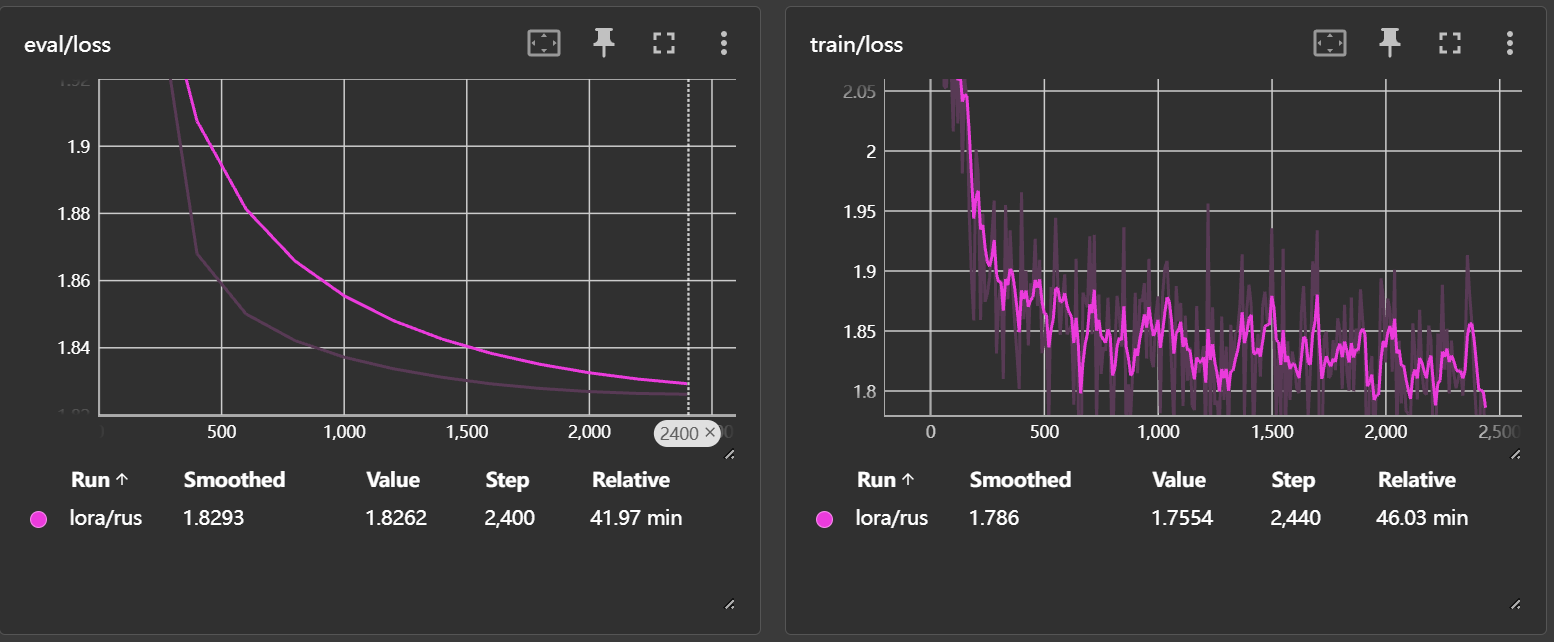